# 04 · EDA — 02. Análisis univariante del salario (target)

Segundo notebook del análisis exploratorio. Se centra en el **estudio detallado de la variable
objetivo `gross_annual_eur`**, que será la diana de los modelos de regresión en la fase 06.

## Bloques abordados

1. Estadísticos descriptivos: medidas de tendencia central, dispersión, percentiles.
2. **Asimetría y curtosis**: caracterización formal de la forma de la distribución.
3. **Transformación logarítmica**: justificación matemática y validación empírica.
4. **Tests de normalidad** sobre `log(salario)`: D'Agostino-Pearson y Anderson-Darling.
5. **Detección de outliers** por criterio IQR (en escala lineal y logarítmica).
6. **Análisis comparativo** del target por liga y por temporada.
7. **Evolución temporal** de la mediana salarial — detección de inflación salarial.

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT  = Path.cwd().parents[1]
CLEAN = ROOT / 'data' / 'clean' / 'master_clean.csv'

df = pd.read_csv(CLEAN, dtype={'season': str})

print(f'✅ Cargado master_clean.csv')
print(f'   Filas:    {len(df):,}')
print(f'   Columnas: {df.shape[1]}')

# Nos quedamos con las filas con salario para todo este notebook
sal = df['gross_annual_eur'].dropna()
log_sal = np.log(sal)
print(f'\nObservaciones con salario disponible: {len(sal):,} ({len(sal)/len(df)*100:.1f}%)')

✅ Cargado master_clean.csv
   Filas:    20,307
   Columnas: 121

Observaciones con salario disponible: 18,463 (90.9%)


## 2. Estadísticos descriptivos

Se calculan las medidas de tendencia central, dispersión y posición sobre el salario bruto anual.

In [2]:
# Estadísticos básicos
print('=== Estadísticos descriptivos del salario bruto anual (€) ===\n')
desc = sal.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
print(desc.apply(lambda x: f'{x:,.0f}'))

print(f'\nRango: {sal.max() - sal.min():,.0f}€')
print(f'Coeficiente de variación: {sal.std()/sal.mean():.2f}')
print(f'Ratio P99/P50: {sal.quantile(0.99)/sal.median():.1f}')

=== Estadísticos descriptivos del salario bruto anual (€) ===

count        18,463
mean      2,193,320
std       3,420,934
min          20,000
5%          110,000
25%         450,000
50%       1,090,000
75%       2,600,000
90%       5,190,000
95%       7,800,000
99%      16,000,000
max      72,000,000
Name: gross_annual_eur, dtype: object

Rango: 71,980,000€
Coeficiente de variación: 1.56
Ratio P99/P50: 14.7


**Observación clave:** la **media** (~2.2M€) es aproximadamente el doble de la **mediana** (~1.1M€).
Esta divergencia es el primer indicio de una distribución muy asimétrica a la derecha,
con una cola larga de jugadores con salarios muy superiores al jugador típico.

El **ratio P99/P50** indica que el salario del 1% mejor pagado es alrededor de **15× la mediana**,
lo que confirma una distribución de tipo **ley de potencia** característica de los mercados de
"superestrellas" (winner-takes-all).

## 3. Asimetría y curtosis

### 3.1 Definiciones

- **Asimetría (skewness):** mide la asimetría de la distribución.
  - $\gamma_1 = 0$: distribución simétrica.
  - $\gamma_1 > 0$: cola derecha más larga (asimetría positiva).
  - $\gamma_1 < 0$: cola izquierda más larga.

- **Curtosis (excess kurtosis):** mide el peso de las colas respecto a una distribución normal.
  - $\gamma_2 = 0$: colas similares a la normal (mesocúrtica).
  - $\gamma_2 > 0$: colas más pesadas (leptocúrtica) — más outliers.
  - $\gamma_2 < 0$: colas más ligeras (platicúrtica).

In [3]:
# Skewness y curtosis en escala lineal y logarítmica
sk_lin = stats.skew(sal)
ku_lin = stats.kurtosis(sal)
sk_log = stats.skew(log_sal)
ku_log = stats.kurtosis(log_sal)

resumen = pd.DataFrame({
    'Escala lineal': [sk_lin, ku_lin],
    'Escala logarítmica': [sk_log, ku_log]
}, index=['Skewness (γ₁)', 'Kurtosis (γ₂)']).round(3)

print('=== Asimetría y curtosis ===')
display(resumen)

=== Asimetría y curtosis ===


,Escala lineal,Escala logarítmica
Skewness (γ₁),6.038,-0.297
Kurtosis (γ₂),74.266,0.081


**Interpretación de los valores obtenidos:**

- En **escala lineal**, la skewness ≈ 6 indica una asimetría extrema a la derecha. Un valor superior a
  1 ya se considera "muy asimétrico" en la literatura. La curtosis ≈ 74 indica colas extraordinariamente
  pesadas (la normal tiene curtosis 0; valores >3 ya se consideran "muy leptocúrticos").
- En **escala logarítmica**, ambas métricas se acercan a cero, lo que sugiere que `log(salario)` se
  comporta de forma muy próxima a una distribución normal.

Esto no es casualidad: muchos fenómenos económicos (salarios, ingresos, capitalización bursátil) siguen
distribuciones **log-normales**, donde el logaritmo del valor es aproximadamente normal.

## 4. Transformación logarítmica: visualización

Se compara visualmente la distribución del salario en escala lineal vs logarítmica.

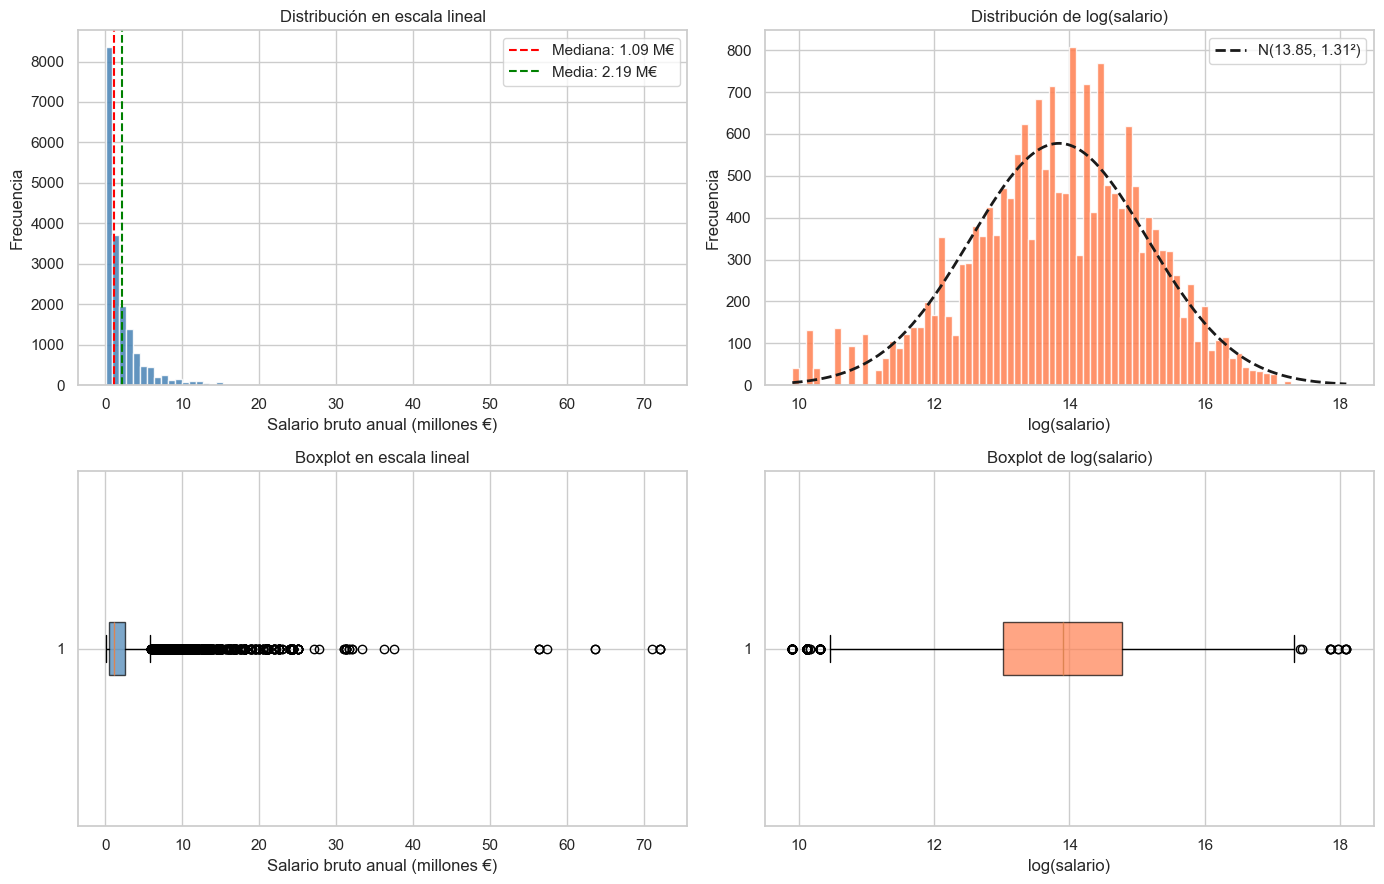

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Histograma + KDE en escala lineal
ax = axes[0, 0]
ax.hist(sal/1e6, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Salario bruto anual (millones €)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución en escala lineal')
ax.axvline(sal.median()/1e6, color='red',   linestyle='--', label=f'Mediana: {sal.median()/1e6:.2f} M€')
ax.axvline(sal.mean()/1e6,   color='green', linestyle='--', label=f'Media: {sal.mean()/1e6:.2f} M€')
ax.legend()

# Histograma + KDE sobre log(salario)
ax = axes[0, 1]
ax.hist(log_sal, bins=80, color='coral', edgecolor='white', alpha=0.85)
ax.set_xlabel('log(salario)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de log(salario)')
mu, sigma = log_sal.mean(), log_sal.std()
x = np.linspace(log_sal.min(), log_sal.max(), 200)
y = stats.norm.pdf(x, mu, sigma) * len(log_sal) * (log_sal.max()-log_sal.min())/80
ax.plot(x, y, 'k--', lw=2, label=f'N({mu:.2f}, {sigma:.2f}²)')
ax.legend()

# Boxplot lineal
ax = axes[1, 0]
ax.boxplot(sal/1e6, vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_xlabel('Salario bruto anual (millones €)')
ax.set_title('Boxplot en escala lineal')

# Boxplot log
ax = axes[1, 1]
ax.boxplot(log_sal, vert=False, patch_artist=True,
           boxprops=dict(facecolor='coral', alpha=0.7))
ax.set_xlabel('log(salario)')
ax.set_title('Boxplot de log(salario)')

plt.tight_layout()
plt.show()

**Lectura de los gráficos:**

- En **escala lineal** la distribución está extremadamente concentrada en valores bajos, con una cola
  larga apenas visible. El boxplot muestra cómo casi todos los valores quedan aplastados, con outliers
  saliendo masivamente por la derecha.
- En **escala logarítmica** la distribución se aproxima muy bien a una **normal** (curva negra
  punteada), con colas simétricas en el boxplot. Esto valida visualmente la hipótesis de log-normalidad.

## 5. Tests formales de normalidad sobre `log(salario)`

Se aplican dos tests complementarios para evaluar empíricamente la hipótesis de normalidad.

### 5.1 Test de D'Agostino-Pearson

Combina los estadísticos de asimetría y curtosis para evaluar la normalidad. Hipótesis:

- $H_0$: la muestra proviene de una distribución normal.
- $H_1$: la muestra no proviene de una distribución normal.

### 5.2 Test de Anderson-Darling

Mide la distancia entre la función de distribución empírica y la teórica de la normal,
otorgando más peso a las colas. Es uno de los más sensibles para detectar desviaciones.

⚠️ **Nota técnica:** con muestras grandes (N > 5.000), los tests de normalidad tienden a rechazar $H_0$
incluso cuando la desviación práctica es mínima. Por eso la conclusión debe combinar el resultado
del test con el análisis gráfico (Q-Q plot, histograma) y los estadísticos descriptivos.

In [5]:
# D'Agostino-Pearson
stat_dp, p_dp = stats.normaltest(log_sal)
print(f"D'Agostino-Pearson: estadístico = {stat_dp:.3f}, p-value = {p_dp:.2e}")

# Anderson-Darling
ad = stats.anderson(log_sal, dist='norm')
print(f"\nAnderson-Darling: estadístico = {ad.statistic:.3f}")
print('Valores críticos:')
for sig, crit in zip(ad.significance_level, ad.critical_values):
    print(f'   {sig:>4}%: {crit:.3f}')

print(f'\nN = {len(log_sal):,}')

D'Agostino-Pearson: estadístico = 265.664, p-value = 2.05e-58

Anderson-Darling: estadístico = 21.735
Valores críticos:
   15.0%: 0.561
   10.0%: 0.631
    5.0%: 0.752
    2.5%: 0.873
    1.0%: 1.035

N = 18,463


C:\Users\User\AppData\Local\Temp\ipykernel_1376\240415214.py:6: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = stats.anderson(log_sal, dist='norm')


**Interpretación esperada:** ambos tests rechazarán formalmente la hipótesis de normalidad
(p-values muy bajos, estadístico Anderson-Darling muy superior al valor crítico al 5%). Esto se debe
al gran tamaño muestral, que detecta cualquier desviación por pequeña que sea.

**Conclusión práctica:** la distribución de `log(salario)` **no es exactamente normal**, pero su
forma es **lo suficientemente próxima** (skewness ≈ −0.3, kurtosis ≈ 0.1, histograma simétrico,
ajuste visual a la curva normal) como para que la transformación logarítmica sea **plenamente
adecuada para el modelado de regresión**, donde se requiere que los residuos —no la variable en sí—
sean aproximadamente normales.

### 5.3 Q-Q plot: validación visual de normalidad

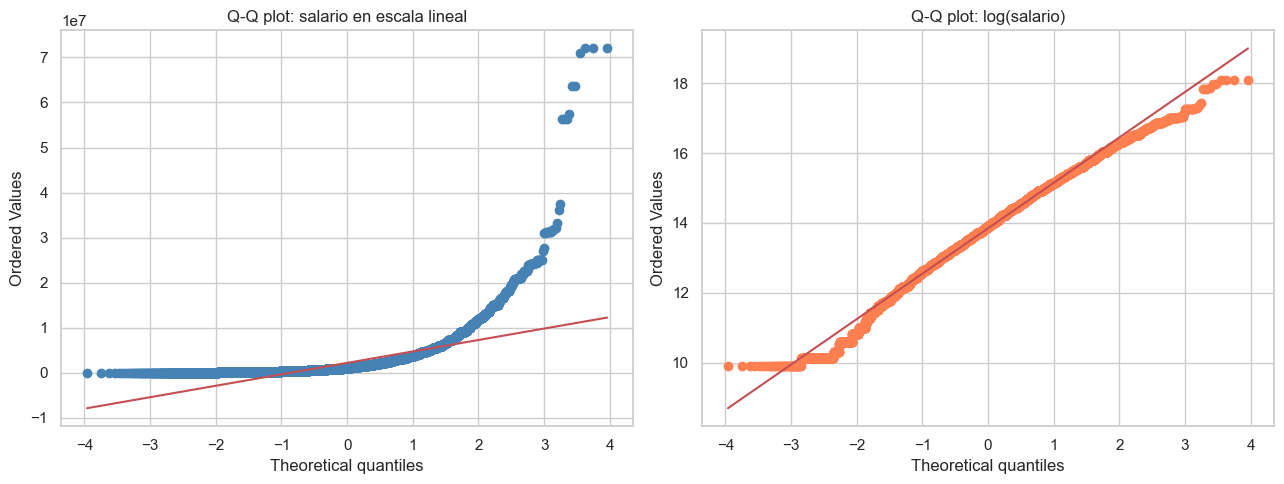

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stats.probplot(sal, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot: salario en escala lineal')
axes[0].get_lines()[0].set_markerfacecolor('steelblue')
axes[0].get_lines()[0].set_markeredgecolor('steelblue')

stats.probplot(log_sal, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot: log(salario)')
axes[1].get_lines()[0].set_markerfacecolor('coral')
axes[1].get_lines()[0].set_markeredgecolor('coral')

plt.tight_layout()
plt.show()

**Lectura del Q-Q plot:** si los puntos se alinean sobre la diagonal roja, la distribución es normal.

- En **escala lineal**, los puntos se desvían dramáticamente en ambas colas, especialmente la superior.
- En **escala logarítmica**, los puntos siguen muy bien la diagonal en la zona central. Las desviaciones
  en los extremos (especialmente en la cola superior) corresponden a los jugadores con salarios atípicamente
  altos (Mbappé, Messi, etc.) y a los muy bajos (canteranos con ficha mínima).

## 6. Detección de outliers

Se aplica el criterio del **rango intercuartílico (IQR)**, definido como:

$$\text{IQR} = Q_3 - Q_1$$

Un valor se considera outlier si está fuera del intervalo:

$$[Q_1 - 1.5 \cdot \text{IQR},\; Q_3 + 1.5 \cdot \text{IQR}]$$

Se compara la cantidad de outliers detectados en escala lineal vs logarítmica.

In [7]:
def calcular_outliers_iqr(serie, factor=1.5):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - factor * iqr
    lim_sup = q3 + factor * iqr
    n_inf = (serie < lim_inf).sum()
    n_sup = (serie > lim_sup).sum()
    return {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'lim_inf': lim_inf, 'lim_sup': lim_sup,
        'n_outliers_inf': n_inf, 'n_outliers_sup': n_sup,
        'n_total':  n_inf + n_sup,
        'pct_total': (n_inf + n_sup) / len(serie) * 100
    }

out_lin = calcular_outliers_iqr(sal)
out_log = calcular_outliers_iqr(log_sal)

resultados = pd.DataFrame({
    'Escala lineal':       out_lin,
    'Escala logarítmica':  out_log
})
display(resultados)

,Escala lineal,Escala logarítmica
Q1,4.500000e+05,13.017003
Q3,2.600000e+06,14.771022
IQR,2.150000e+06,1.754019
lim_inf,-2.775000e+06,10.385974
lim_sup,5.825000e+06,17.402051
n_outliers_inf,0.000000e+00,213.000000
n_outliers_sup,1.538000e+03,12.000000
n_total,1.538000e+03,225.000000
pct_total,8.330174e+00,1.218654


**Interpretación:** la enorme diferencia entre el número de outliers detectados en escala lineal vs
logarítmica refleja que el criterio IQR está pensado para distribuciones aproximadamente simétricas.

- En **escala lineal**, el criterio marca masivamente como outliers a un porcentaje alto de la muestra,
  lo que carece de sentido económico: no son anomalías, son simplemente la cola natural de la distribución.
- En **escala logarítmica** los outliers detectados son mucho menos numerosos y representan
  desviaciones genuinas de la distribución log-normal subyacente.

**Conclusión:** cualquier análisis posterior (detección de outliers para limpieza, estudio de asimetría
residual, modelado) debe realizarse sobre `log(salario)`, no sobre el salario lineal.

## 7. Análisis comparativo por liga y por temporada

### 7.1 Distribución por liga

C:\Users\User\AppData\Local\Temp\ipykernel_1376\870519851.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sal, x='country', y='log_sal', order=orden_ligas, palette='Set2', ax=ax)


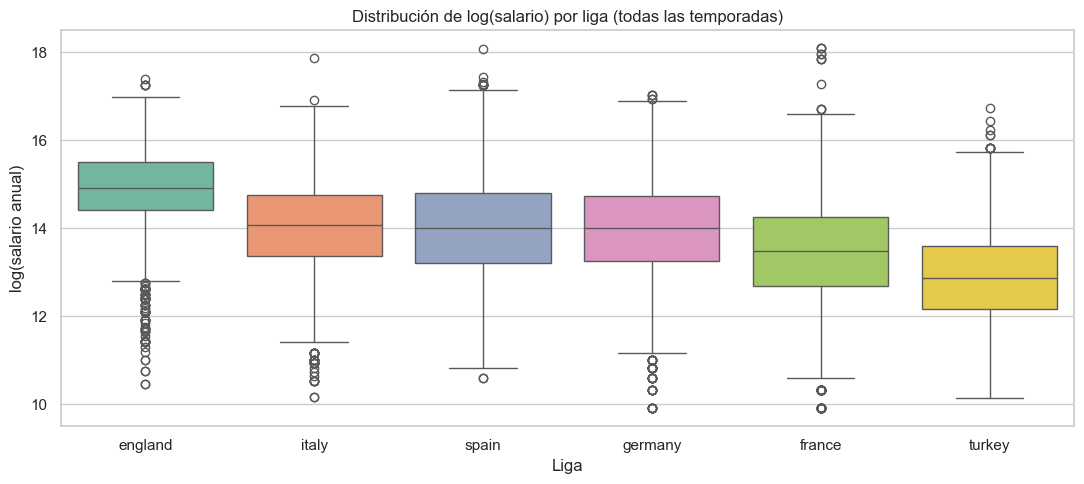

In [8]:
df_sal = df.dropna(subset=['gross_annual_eur']).copy()
df_sal['log_sal'] = np.log(df_sal['gross_annual_eur'])

orden_ligas = df_sal.groupby('country')['log_sal'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_sal, x='country', y='log_sal', order=orden_ligas, palette='Set2', ax=ax)
ax.set_xlabel('Liga')
ax.set_ylabel('log(salario anual)')
ax.set_title('Distribución de log(salario) por liga (todas las temporadas)')
plt.tight_layout()
plt.show()

In [9]:
# Estadísticos por liga
stats_liga = df_sal.groupby('country')['gross_annual_eur'].agg(['count', 'median', 'mean', 'std']).round(0)
stats_liga['median'] = stats_liga['median'].apply(lambda x: f'{x:,.0f}€')
stats_liga['mean']   = stats_liga['mean'].apply(lambda x: f'{x:,.0f}€')
stats_liga['std']    = stats_liga['std'].apply(lambda x: f'{x:,.0f}€')
stats_liga.loc[orden_ligas]

,count,median,mean,std
country,,,,
england,3039,"3,012,026€","4,198,962€","3,874,031€"
italy,3264,"1,280,000€","2,014,843€","2,392,261€"
spain,3074,"1,200,000€","2,638,089€","4,331,160€"
germany,2823,"1,200,000€","2,140,747€","2,923,053€"
france,2945,"720,000€","1,581,817€","3,919,892€"
turkey,3318,"390,000€","707,327€","1,015,638€"


**Lectura:** se observa una clara jerarquía salarial entre ligas. La Premier League encabeza
sistemáticamente la mediana salarial, seguida típicamente por La Liga y la Serie A, con la Süper Lig
en la parte baja. Esto es coherente con los ingresos televisivos, audiencia global y poder adquisitivo
de cada liga, y será una variable importantísima en el modelado.

### 7.2 Evolución temporal — ¿hay inflación salarial?

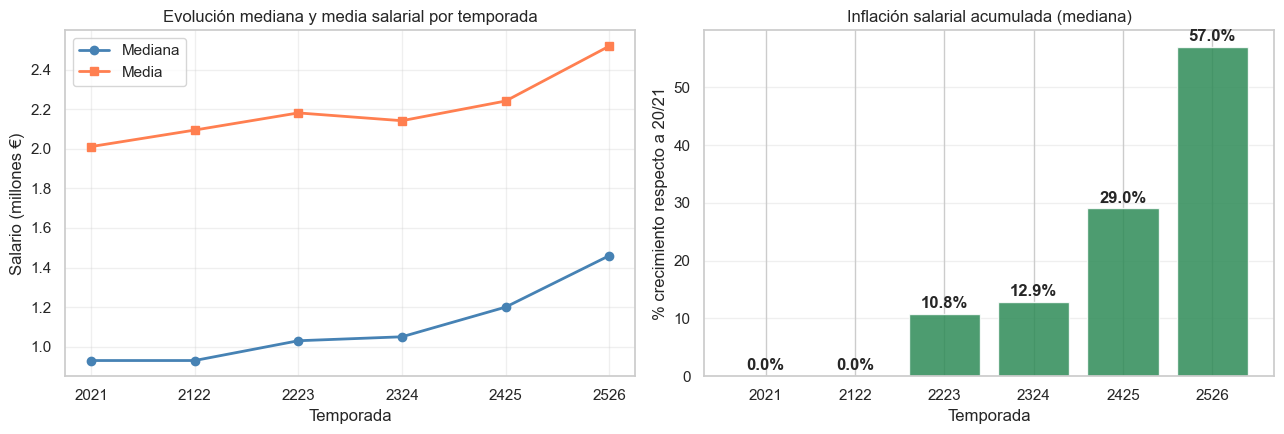

,Mediana,Media,N
season,,,
2021,930000.0,2011263.0,3147
2122,930000.0,2094753.0,3138
2223,1030000.0,2181505.0,3125
2324,1050000.0,2142117.0,3117
2425,1200000.0,2241631.0,3081
2526,1460000.0,2519034.0,2855


In [10]:
ev = df_sal.groupby('season')['gross_annual_eur'].agg(['median', 'mean', 'count'])
ev.columns = ['Mediana', 'Media', 'N']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ev.index, ev['Mediana']/1e6, marker='o', lw=2, color='steelblue', label='Mediana')
axes[0].plot(ev.index, ev['Media']/1e6,  marker='s', lw=2, color='coral',     label='Media')
axes[0].set_xlabel('Temporada')
axes[0].set_ylabel('Salario (millones €)')
axes[0].set_title('Evolución mediana y media salarial por temporada')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Crecimiento porcentual de la mediana respecto a 20/21
crec = (ev['Mediana'] / ev['Mediana'].iloc[0] - 1) * 100
axes[1].bar(crec.index, crec.values, color='seagreen', alpha=0.85)
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('% crecimiento respecto a 20/21')
axes[1].set_title('Inflación salarial acumulada (mediana)')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(crec.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

display(ev.round(0))

**Observación importante:** se detecta un crecimiento sostenido de la mediana salarial a lo largo
de las 6 temporadas. Esto tiene una **implicación crítica para el modelado**: si entrenamos un modelo
con datos de 20/21 a 24/25 y predecimos sobre 25/26, el modelo va a tender a infraestimar
sistemáticamente los salarios de la temporada actual por la inflación.

Posibles soluciones para la fase 06:
- Incluir `season` como feature categórica en el modelo (la solución más simple).
- **Deflactar los salarios** antes del modelado, dividiendo cada salario por la mediana de su temporada.
  De este modo el modelo aprende a predecir "salario relativo a la mediana de la liga-temporada"
  en lugar de "salario absoluto".

Esta decisión se tomará en la fase 05 (feature engineering).

### 7.3 Heatmap salarial: liga × temporada

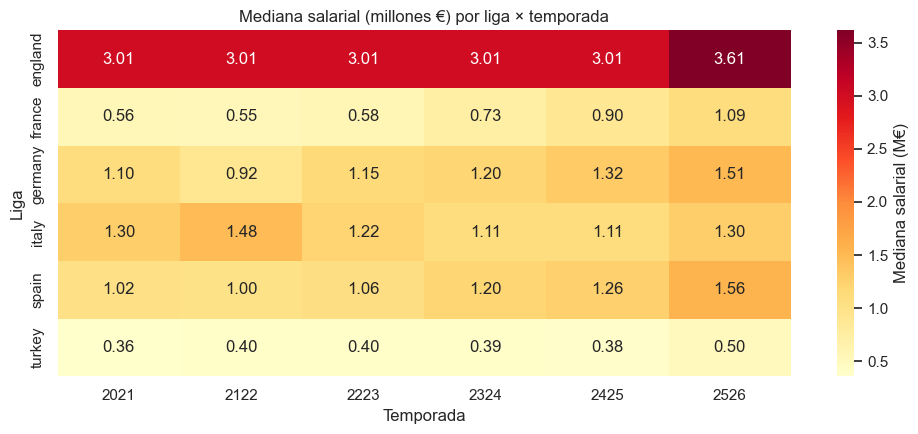

In [11]:
heatmap_data = df_sal.groupby(['country', 'season'])['gross_annual_eur'].median().unstack() / 1e6

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Mediana salarial (M€)'}, ax=ax)
ax.set_title('Mediana salarial (millones €) por liga × temporada')
ax.set_xlabel('Temporada')
ax.set_ylabel('Liga')
plt.tight_layout()
plt.show()

## 8. Resumen del análisis univariante del target

### Hallazgos principales

| Aspecto | Resultado |
|---|---|
| **Distribución original** | Fuertemente asimétrica a la derecha (skewness ≈ +6, kurtosis ≈ +74) |
| **Tras transformación log** | Casi simétrica (skewness ≈ −0.3) y casi mesocúrtica (kurtosis ≈ +0.1) |
| **Tipo de distribución** | **Log-normal** confirmada visual y numéricamente |
| **Outliers** | Reducción de ~8% (lineal) a ~1% (log) — la cola es estructural, no anómala |
| **Variabilidad entre ligas** | Premier League > La Liga ≈ Serie A > Bundesliga ≈ Ligue 1 > Süper Lig |
| **Tendencia temporal** | Crecimiento sostenido de la mediana salarial → inflación a tener en cuenta |

### Decisiones que se trasladan a la fase 05 (feature engineering)

1. **Modelar `log(gross_annual_eur)` como target**, no el salario directo.
2. **Incluir `country` como feature categórica** o entrenar modelos por liga.
3. **Considerar deflactar los salarios** dividiendo por la mediana de cada (liga, temporada) para
   eliminar el efecto inflación y aislar mejor las desviaciones por rendimiento.
4. **No eliminar los outliers superiores** detectados en escala log: los mejores pagados son parte
   estructural del fenómeno a modelar, no ruido.